# Credit Risk & Portfolio Analytics
## Phase 1: Investor Framing and Exploratory Data Analysis

### The Question
If you were an anonymous investor on LendingClub, which loans would you fund?

LendingClub assigns every loan a grade from A to G based on their internal risk model. 
You could simply follow their grades — but that raises a more interesting question: 
can raw borrower characteristics predict default risk independently of LendingClub's 
own assessment? And even if you can predict default well, does that actually translate 
to better investment returns?

This notebook is the first step toward answering both questions. The goal here is to 
understand the data — its structure, its quirks, and the signals that might actually 
matter for a lending investor.

**Note:** This is a cold-start problem. Each row is a unique borrower — we have no 
prior behavioral history for any individual. We predict default purely from borrower 
characteristics at origination time.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

%matplotlib inline

## 1. Data Loading

In [36]:
files = glob.glob('../2003_download/*.csv')
print(f"Found {len(files)} files")

dfs = []
for f in files:
    df_temp = pd.read_csv(f, low_memory=False, header=1)
    dfs.append(df_temp)

df_main = pd.concat(dfs, ignore_index=True)
print(f"Full dataset shape: {df_main.shape}")

Found 20 files
Full dataset shape: (2777817, 151)


In [37]:
# Confirm cold-start: each row is a unique borrower
print(f"Total loans: {df_main['id'].nunique()}")
print(f"Total rows: {len(df_main)}")
# If equal, no repeat borrowers — pure cold-start prediction problem

Total loans: 2777817
Total rows: 2777817


## 2. Basic Data Profiling

In [38]:
df_main.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,...,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,disbursement_method
0,145596557,NaN,10000.00,10000.00,10000.00,60 months,16.14%,243.93,C,C4,Sale Consultant,2 years,RENT,90000.00,Not Verified,Dec-2018,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,079xx,NJ,8.80,0.00,Mar-1991,660.00,664.00,1.00,NaN,43.00,11.00,1.00,10582.00,58.5%,32.00,w,0.00,0.00,10661.06,10661.06,10000.00,661.06,0.00,0.00,0.00,May-2019,9698.79,NaN,...,6.00,11.00,0.00,0.00,0.00,1.00,100.00,80.00,1.00,0.00,25600.00,15470.00,15000.00,7500.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,145632711,NaN,6500.00,6500.00,6500.00,36 months,11.80%,215.28,B,B4,Educator,2 years,RENT,46500.00,Source Verified,Dec-2018,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,352xx,AL,21.01,0.00,Aug-2011,690.00,694.00,1.00,61.00,NaN,24.00,0.00,6741.00,41.6%,30.00,w,4411.89,4411.89,2792.25,2792.25,2088.11,704.14,0.00,0.00,0.00,Feb-2020,0.00,Mar-2020,...,10.00,24.00,0.00,0.00,0.00,9.00,93.30,0.00,0.00,0.00,50845.00,40223.00,13300.00,34645.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,145636374,NaN,4500.00,4500.00,4500.00,36 months,11.31%,147.99,B,B3,Accounts Examiner III,10+ years,RENT,38500.00,Not Verified,Dec-2018,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,credit_card,Credit card refinancing,786xx,TX,4.64,0.00,Dec-2003,675.00,679.00,0.00,25.00,NaN,12.00,0.00,4472.00,15.3%,25.00,w,0.00,0.00,4549.22,4549.22,4500.00,49.22,0.00,0.00,0.00,Feb-2019,4553.46,NaN,...,5.00,12.00,0.00,0.00,0.00,4.00,91.70,0.00,0.00,0.00,53795.00,29137.00,15100.00,24595.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,145636697,NaN,25000.00,25000.00,25000.00,60 months,14.47%,587.82,C,C2,teacher,10+ years,OWN,110000.00,Not Verified,Dec-2018,Late (31-120 days),n,https://lendingclub.com/browse/loanDetail.acti...,NaN,credit_card,Credit card refinancing,117xx,NY,26.43,1.00,Jan-1997,715.00,719.00,0.00,7.00,NaN,23.00,0.00,39053.00,45.7%,49.00,w,21975.89,21975.89,5848.05,5848.05,3024.11,2823.94,0.00,0.00,0.00,Oct-2019,587.82,Mar-2020,...,13.00,23.00,0.00,0.00,1.00,1.00,98.00,10.00,0

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2777817 entries, 0 to 2777816
Columns: 151 entries, id to disbursement_method
dtypes: float64(111), object(40)
memory usage: 3.1+ GB


In [39]:
df_main.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,...,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.00,2777776.00,2777776.00,2777776.00,2777776.00,2777772.00,2774921.00,2777747.00,2777776.00,2777776.00,2777746.00,1327290.00,414155.00,2777747.00,2777747.00,2777776.00,2777747.00,2777776.00,2777776.00,2777776.00,2777776.00,2777776.00,2777776.00,2777776.00,2777776.00,2777776.00,2777776.00,2777776.00,2777776.00,2777631.00,693409.00,2777776.00,192470.00,192466.00,2777747.00,2707500.00,2707500.00,1911646.00,1911647.00,1911647.00,1911647.00,1853790.00,1911647.00,1636758.00,1911647.00,1911647.00,1911647.00,1911311.00,2707500.00,1911647.00,...,2707500.00,2727746.00,2698454.00,622048.00,2420240.00,889535.00,2707500.00,2707500.00,2707500.00,2719186.00,2707500.00,2707500.00,2707500.00,2707499.00,2707500.00,2719186.00,2617035.00,2707500.00,2707500.00,2707500.00,2707345.00,2696105.00,2776411.00,2777671.00,2707500.00,2727746.00,2727746.00,2707500.00,179780.00,179781.00,179781.00,179781.00,179781.00,179781.00,176786.00,179781.00,179781.00,179781.00,179781.00,57848.00,8945.00,8945.00,8945.00,8945.00,7188.00,8945.00,8945.00,23488.00,23488.00,23488.00
mean,NaN,15311.92,15307.64,15292.35,451.34,79385.87,19.18,0.29,700.06,704.06,0.56,34.88,74.30,11.65,0.18,16863.23,24.00,6485.22,6483.77,9992.19,9977.63,7795.94,2107.13,1.08,88.04,14.52,2905.34,693.27,683.52,0.02,44.52,1.00,129347.67,19.34,0.00,220.41,144467.49,0.93,2.81,0.69,1.59,20.68,36417.28,69.03,1.26,2.67,5961.45,56.44,35863.02,1.05,...,8.35,1.52,25.03,39.33,7.11,36.02,0.49,3.69,5.61,4.83,7.62,8.48,8.25,13.81,5.56,11.66,0.00,0.00,0.08,2.07,94.25,40.56,0.12,0.04,181771.05,52170.04,24343.11,44921.92,35743.99,672.68,676.68,0.62,1.56,11.52,56.90,3.05,12.50,0.04,0.07,37.50,3.00,161.38,3.00,12.69,474.73,12391.39,196.64,5628.13,48.69,13.08
std,NaN,9434.45,9433.12,9436.80,271.97,111674.19,15.49,0.85,33.56,33.57,0.86,21.90,26.45,5.71,0.53,22943.95,12.05,8422.80,8421.79,8988.45,8982.28,7712.33,2322.40,9.05,566.92,98.42,5763.67,67.01,97.65,0.15,21.59,0.00,83219.11,7.95,0.06,7689.95,163021.73,1.14,3.00,0.93,1.58,25.39,45421.74,23.66,1.49,2.56,5856.57,20.80,37083.08,1.49,...,9.22,1.87,32.61,22.57,5.99,22.28,1.36,2.36,3.40,3.09,4.68,7.40,4.75,8.03,3.33,5.72,0.02,0.05,0.48,1.84,9.00,36.07,0.36,0.34,184159.42,51326.19,24008.20,46265.25,30485.81,44.43,44.43,0.98,1.78,6.67,25.80,3.26,8.18,0.37,0.38,23.75,0.00,128.85,0.00,9.75,376.75,7884.41,199.85,4019.41,

In [50]:
for i in df_main.columns:
    print(i)

id
member_id
loan_amnt
funded_amnt
funded_amnt_inv
term
int_rate
installment
grade
sub_grade
emp_title
emp_length
home_ownership
annual_inc
verification_status
issue_d
loan_status
pymnt_plan
url
desc
purpose
title
zip_code
addr_state
dti
delinq_2yrs
earliest_cr_line
fico_range_low
fico_range_high
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
revol_util
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
last_fico_range_high
last_fico_range_low
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_coll_amt
tot_cur_bal
open_acc_6m
open_act_il
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
open_rv_24m
max_bal_bc
all_util
total_rev_hi_lim
inq_fi
to

In [41]:
df_main.shape

(2777817, 151)

## 3. Column Selection

151 columns is too many to work with. We trim to two sets:

**`feature_cols`** — available at loan origination time, usable in a predictive model  
**`eda_only_cols`** — outcome variables generated after the loan is issued (data leakage if used in modeling, but useful for EDA)

**Important:** `grade` and `sub_grade` are derived by LendingClub's internal model, 
not raw borrower characteristics. Including them in a predictive model means you're 
partially predicting default using LendingClub's own risk assessment — not independent 
signal. We keep them for EDA but will investigate their leakage impact in Phase 3.

In [43]:
# Post-origination outcome variables — EDA only, never use as model features
eda_only_cols = [
    'id',
    'loan_status',          # target variable
    'total_pymnt',          # payments received after loan issued
    'recoveries',           # collected after default — only exists post-default
    'out_prncp',            # outstanding principal — changes over loan lifetime
    'last_fico_range_high', # FICO score after loan issuance
    'last_fico_range_low',
    'last_pymnt_d'          # Needed for returns calculation in Phase 3
]

# Origination-time features — available when investor makes funding decision
feature_cols = [
    'loan_amnt', 'funded_amnt', 'term', 'int_rate',
    'grade', 'sub_grade',           # NOTE: LendingClub-derived
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'issue_d', 'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line',
    'open_acc', 'pub_rec', 'fico_range_high', 'fico_range_low',
    'revol_bal', 'revol_util', 'inq_last_6mths', 'pub_rec_bankruptcies',
    'addr_state', 'total_acc', 'mths_since_last_delinq',
    'sec_app_fico_range_high', 'sec_app_fico_range_low'  # joint applications
]

df = df_main[feature_cols + eda_only_cols]
print(f"Trimmed dataset shape: {df.shape}")

Trimmed dataset shape: (2777817, 36)


## 4. Type Conversion

In [44]:
df['int_rate'] = df['int_rate'].str.replace('%', '').str.strip().astype(float)
df['revol_util'] = df['revol_util'].str.replace('%', '').str.strip().astype(float)
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')

print("Type cleaning complete")
print(df[['int_rate', 'revol_util', 'issue_d']].dtypes)

/var/folders/2b/mx4d8bfx64b0_mwy0_qmj1sh0000gn/T/ipykernel_36656/1829268859.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['int_rate'] = df['int_rate'].str.replace('%', '').str.strip().astype(float)
/var/folders/2b/mx4d8bfx64b0_mwy0_qmj1sh0000gn/T/ipykernel_36656/1829268859.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['revol_util'] = df['revol_util'].str.replace('%', '').str.strip().astype(float)


Type cleaning complete
int_rate             float64
revol_util           float64
issue_d       datetime64[ns]
dtype: object


/var/folders/2b/mx4d8bfx64b0_mwy0_qmj1sh0000gn/T/ipykernel_36656/1829268859.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')


## 5. Defining Default

We create a binary outcome variable `is_default`. 

Loan statuses defined by LendingClub:
- **Current** — being repaid on time
- **Late (16-30 days / 31-120 days)** — payment overdue
- **Default** - 121+ days past due
- **Charged Off** — LendingClub has written off the loan as uncollectable

**Note on Current loans:** 1.56M loans are still Current. They haven't reached their 
final status yet and some will eventually default. This means our measured default rate 
*understates* the true rate. For modeling in Phase 3, we filter to completed loans only.

In [45]:
default_statuses = [
    'Charged Off',
    'Default',
    'Late (31-120 days)',
    'Late (16-30 days)',
    'Does not meet the credit policy. Status:Charged Off'
]

df['is_default'] = df['loan_status'].isin(default_statuses).astype(int)

print("Loan status distribution:")
print(df['loan_status'].value_counts())
print(f"\nOverall default rate: {df['is_default'].mean():.1%}")
print(f"Class imbalance defaults: {df['is_default'].sum():,} / {len(df):,}")

/var/folders/2b/mx4d8bfx64b0_mwy0_qmj1sh0000gn/T/ipykernel_36656/4221899376.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_default'] = df['loan_status'].isin(default_statuses).astype(int)


Loan status distribution:
loan_status
Current                                                1559756
Fully Paid                                              913478
Charged Off                                             238118
Late (31-120 days)                                       34061
In Grace Period                                          19614
Late (16-30 days)                                         9055
Does not meet the credit policy. Status:Fully Paid        1988
Default                                                    945
Does not meet the credit policy. Status:Charged Off        761
Name: count, dtype: int64

Overall default rate: 10.2%
Class imbalance defaults: 282,940 / 2,777,817


## 6. Grade Distribution

The first thing an investor wants to understand is the composition of the loan portfolio.

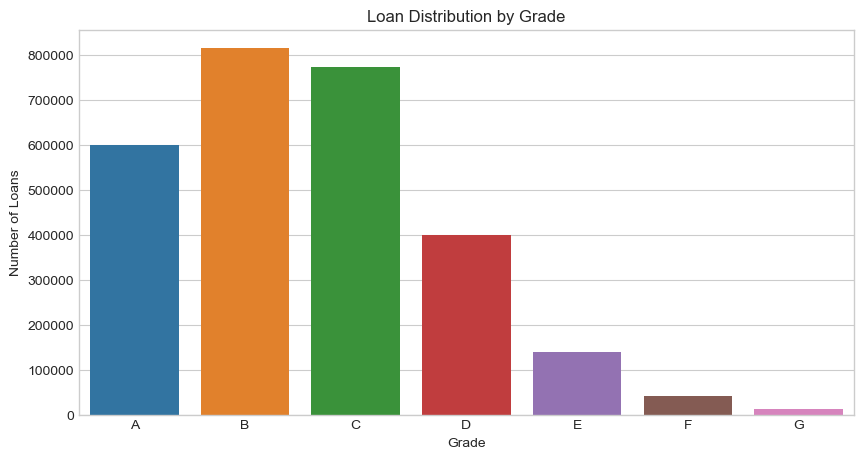

In [18]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='grade', order=sorted(df['grade'].dropna().unique()))
plt.title('Loan Distribution by Grade')
plt.xlabel('Grade')
plt.ylabel('Number of Loans')
plt.show()

Grade B and C dominate the portfolio (~28% each). Grade A is underrepresented as 
the safest borrowers often access cheaper credit through traditional banks. 
The high-risk tail (E, F, G) is thin due to LendingClub's origination screening.

## 7. Default Rate by Grade

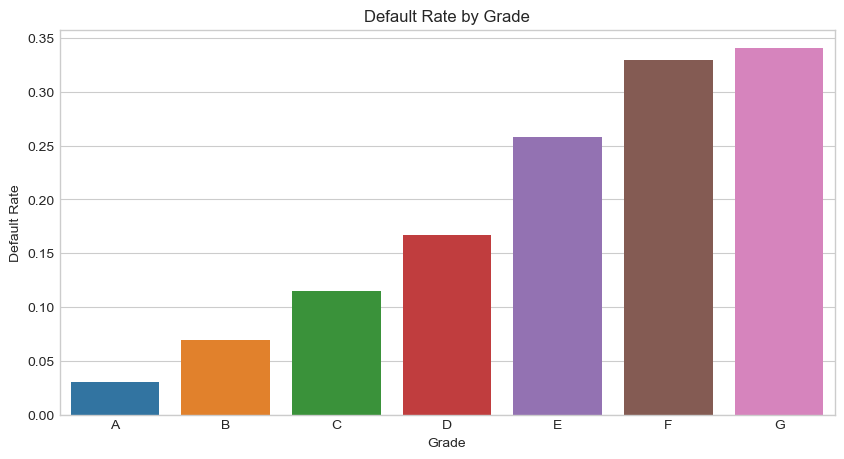

In [19]:
df_grade = df.groupby('grade')['is_default'].mean().reset_index().sort_values('grade')

plt.figure(figsize=(10, 5))
sns.barplot(data=df_grade, x='grade', y='is_default')
plt.title('Default Rate by Grade')
plt.xlabel('Grade')
plt.ylabel('Default Rate')
plt.show()

Default rates increase linearly from ~9% (Grade A) to ~55% (Grade G). 
An investor might instinctively choose Grade A, but that ignores the interest rate story.

## 8. Interest Rate by Grade: The Risk-Return Tradeoff

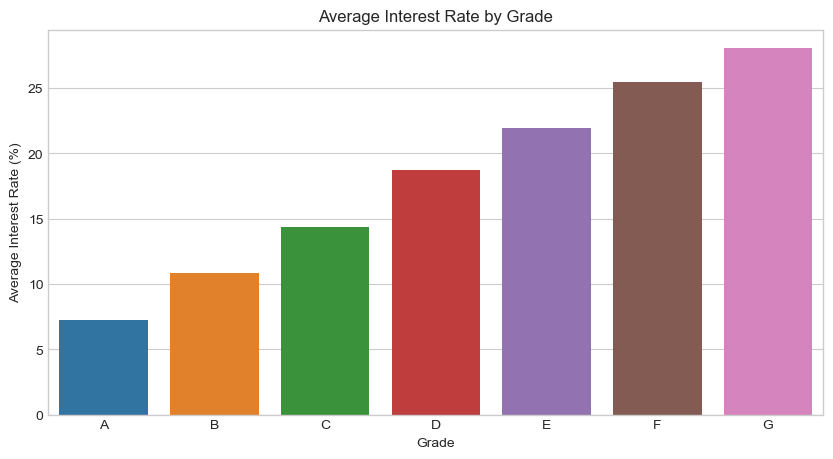

In [20]:
df_grade_int = df.groupby('grade')['int_rate'].mean().reset_index().sort_values('grade')

plt.figure(figsize=(10, 5))
sns.barplot(data=df_grade_int, x='grade', y='int_rate')
plt.title('Average Interest Rate by Grade')
plt.xlabel('Grade')
plt.ylabel('Average Interest Rate (%)')
plt.show()

### The Risk-Return Tradeoff

Grade A loans default at ~9% but yield only ~7.25% interest. 
Grade G loans default at ~55% but yield ~28% interest. 

The question isn't which grade has the lowest default rate. Tt's which grade offers 
the best **risk-adjusted return** after accounting for default losses. This is what 
motivates the return analysis in Phase 3.

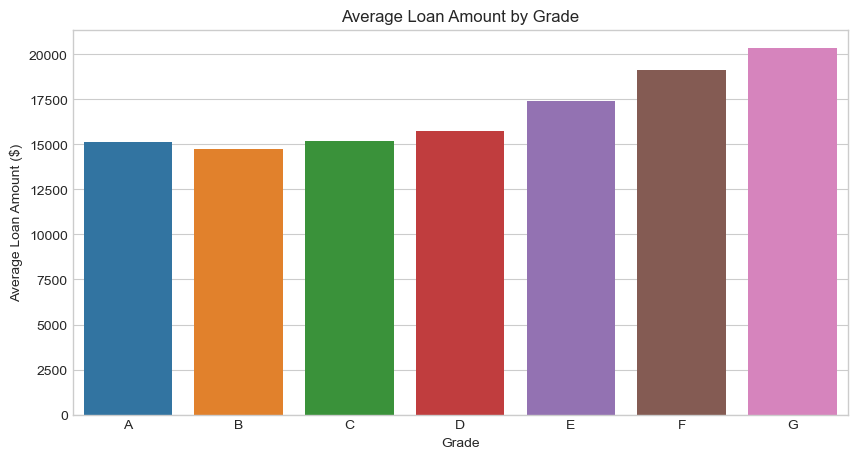

In [21]:
df_grade_loan = df.groupby('grade')['loan_amnt'].mean().reset_index().sort_values('grade')

plt.figure(figsize=(10, 5))
sns.barplot(data=df_grade_loan, x='grade', y='loan_amnt')
plt.title('Average Loan Amount by Grade')
plt.xlabel('Grade')
plt.ylabel('Average Loan Amount ($)')
plt.show()

Higher-risk borrowers take out larger loans on average. 
Loan amount is an input into LendingClub's grading model. Larger loans relative 
to income signal higher risk. Many lower-grade borrowers are consolidating 
significant existing debt.

## 9. Loan Purpose Analysis

In [22]:
print("Loan purpose distribution:")
print(df['purpose'].value_counts())

Loan purpose distribution:
purpose
debt_consolidation    1559217
credit_card            656008
home_improvement       182415
other                  169050
major_purchase          59644
medical                 33476
small_business          28729
car                     28559
vacation                19313
house                   18655
moving                  18234
wedding                  2355
renewable_energy         1697
educational               424
Name: count, dtype: int64


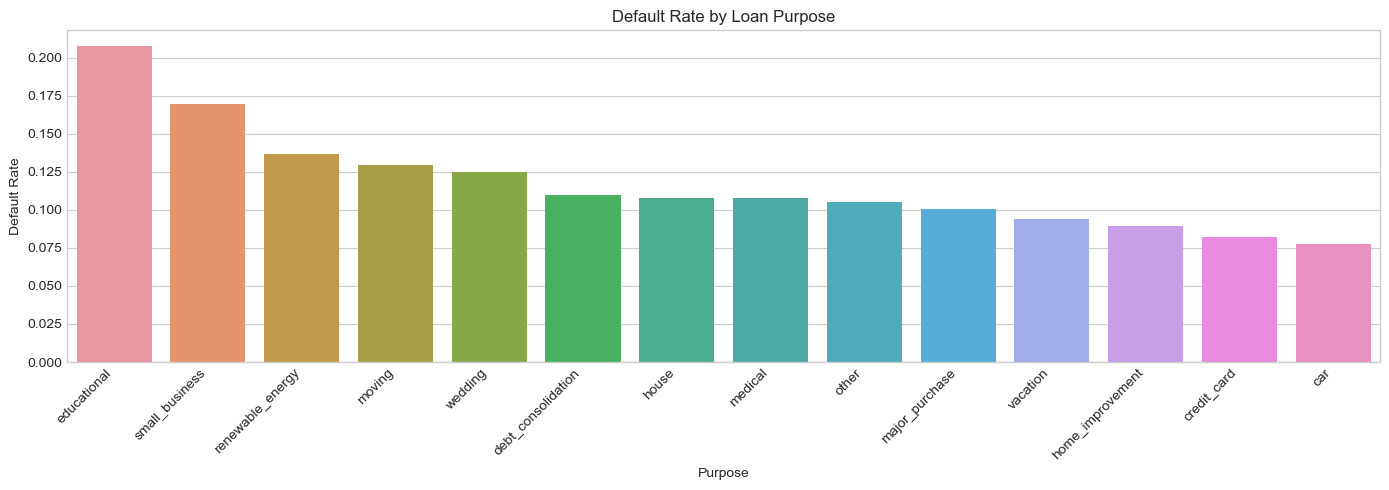

In [23]:
# Default rate by purpose
df_purpose = df.groupby('purpose')['is_default'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 5))
sns.barplot(data=df_purpose, x='purpose', y='is_default')
plt.title('Default Rate by Loan Purpose')
plt.xlabel('Purpose')
plt.ylabel('Default Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [24]:
# Purpose distribution within each grade
pd.crosstab(df['purpose'], df['grade'], normalize='columns').round(3) * 100

grade,A,B,C,D,E,F,G
purpose,,,,,,,
car,1.30,1.10,0.90,0.90,0.70,0.70,0.60
credit_card,33.00,26.70,20.50,15.40,11.60,9.00,7.10
debt_consolidation,48.10,54.50,59.20,61.80,64.20,64.60,62.30
educational,0.00,0.00,0.00,0.00,0.00,0.00,0.10
home_improvement,7.50,6.60,6.30,5.90,6.00,6.00,6.10
house,0.60,0.60,0.60,0.80,1.00,1.40,2.50
major_purchase,2.30,2.10,2.00,2.10,2.10,2.10,2.10
medical,1.00,1.10,1.30,1.50,1.40,1.40,1.10
moving,0.40,0.50,0.70,1.00,1.10,1.30,1.20


Small business and educational loans carry the highest default risk. Both involve 
uncertain future income streams. Debt consolidation dominates volume (~56% of loans) 
with moderate default risk. Purpose adds meaningful signal beyond grade alone.

## 10. Default Rate Over Time

/Users/sushanth/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/sushanth/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


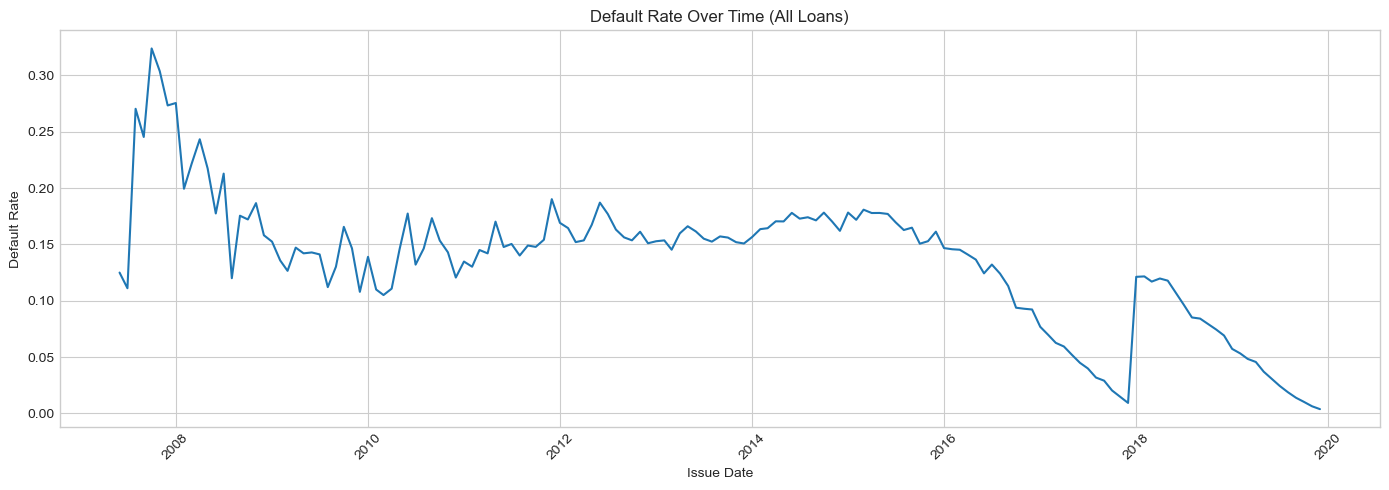

In [27]:
# Exclude current loans for a cleaner default rate signal
df_time = df.groupby('issue_d')['is_default'].mean().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=df_time, x='issue_d', y='is_default')
plt.title('Default Rate Over Time (All Loans)')
plt.xlabel('Issue Date')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/Users/sushanth/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/sushanth/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


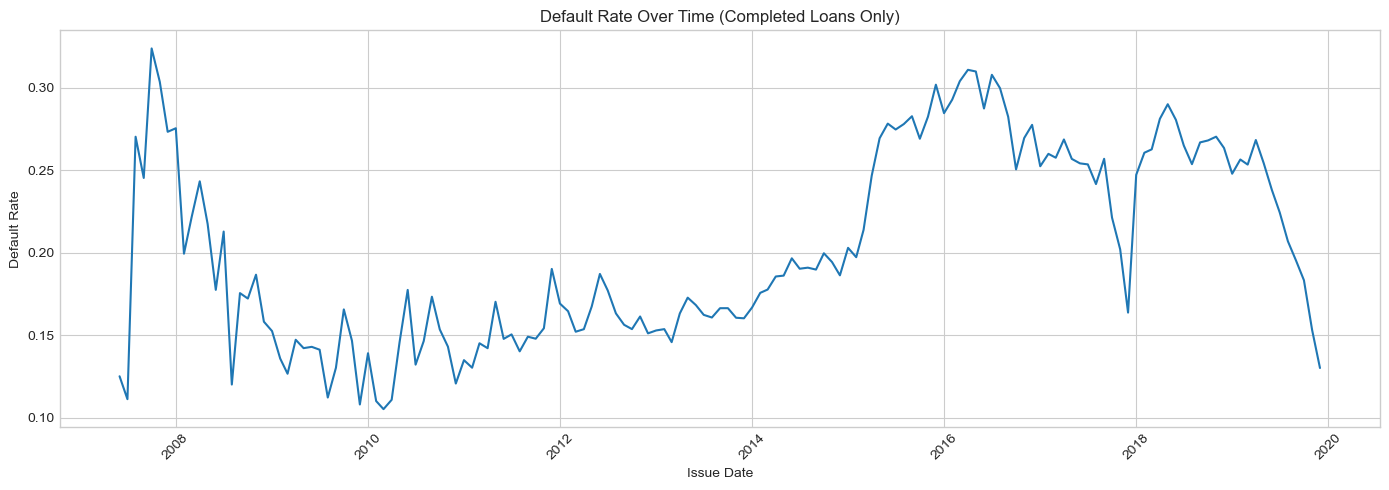

In [25]:
# Exclude current loans for a cleaner default rate signal
df_completed = df[df['loan_status'] != 'Current']
df_time = df_completed.groupby('issue_d')['is_default'].mean().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=df_time, x='issue_d', y='is_default')
plt.title('Default Rate Over Time (Completed Loans Only)')
plt.xlabel('Issue Date')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/Users/sushanth/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/sushanth/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


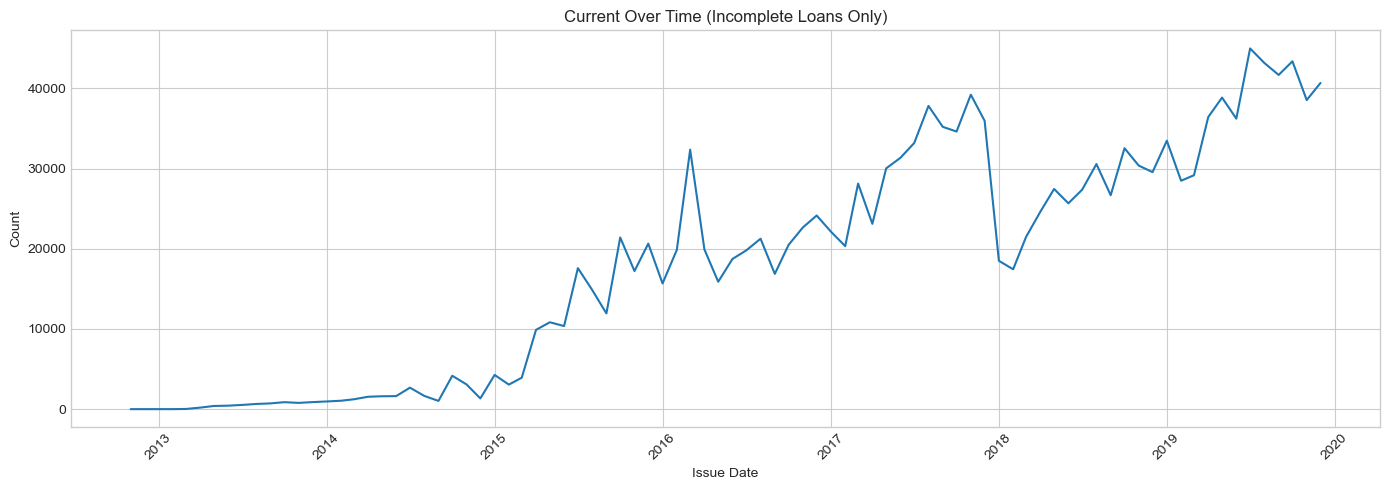

In [63]:
# Exclude current loans for a cleaner default rate signal
df_incomplete = df[df['loan_status'] == 'Current']
df_time = df_incomplete.groupby('issue_d').size().reset_index()
df_time.columns=['issue_d','loan_status']

plt.figure(figsize=(14, 5))
sns.lineplot(data=df_time, x='issue_d', y='loan_status')
plt.title('Current Over Time (Incomplete Loans Only)')
plt.xlabel('Issue Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Observations

- **2008 spike:** Global Financial Crisis borrowers who looked fine at origination 
  suddenly couldn't make payments. A model trained on 2008 data will be overly 
  pessimistic.

- **Steady decline post-2008:** Economic recovery + tighter underwriting standards.

- **Sharp drop post-2017:** This is a **data artifact**, not a real improvement. 
  Recent loans haven't had enough time to default yet as they're still Current. 
  
**Modeling implication:** We filter to loans issued before 2018 to ensure we only 
train on loans with fully resolved outcomes.

/Users/sushanth/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/sushanth/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


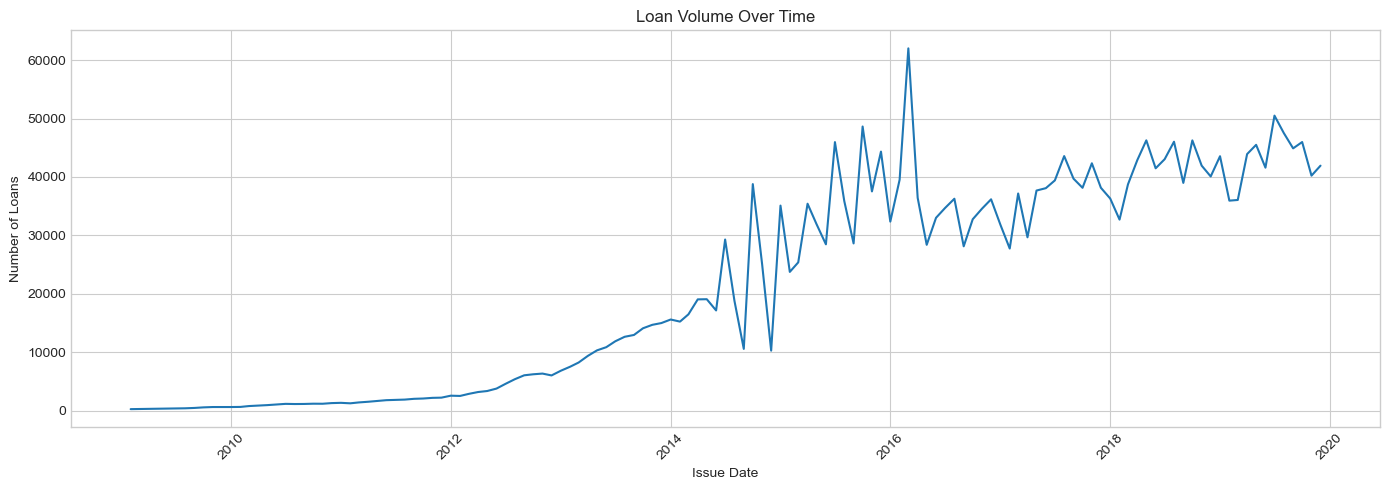

In [28]:
df_vol = df[df['issue_d'] > '2009-01-01'].groupby('issue_d').size().reset_index(name='count')

plt.figure(figsize=(14, 5))
sns.lineplot(data=df_vol, x='issue_d', y='count')
plt.title('Loan Volume Over Time')
plt.xlabel('Issue Date')
plt.ylabel('Number of Loans')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Missing Value Analysis

In [29]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0])

sec_app_fico_range_high   93.53
sec_app_fico_range_low    93.53
mths_since_last_delinq    52.22
emp_length                 6.95
dti                        0.10
revol_util                 0.09
pub_rec_bankruptcies       0.05
inq_last_6mths             0.00
delinq_2yrs                0.00
earliest_cr_line           0.00
open_acc                   0.00
pub_rec                    0.00
total_acc                  0.00
annual_inc                 0.00
loan_status                0.00
total_pymnt                0.00
recoveries                 0.00
out_prncp                  0.00
last_fico_range_high       0.00
addr_state                 0.00
last_fico_range_low        0.00
loan_amnt                  0.00
fico_range_low             0.00
revol_bal                  0.00
funded_amnt                0.00
fico_range_high            0.00
purpose                    0.00
issue_d                    0.00
verification_status        0.00
home_ownership             0.00
sub_grade                  0.00
grade   

### Missing Value Summary

- **`sec_app_fico_range_*` — 93.5% missing:** Only populated for joint applications. 
  Will handle separately or drop in Phase 2.
  
- **`mths_since_last_delinq` — 52% missing:** Missing means *never delinquent*, 
  not unknown. Will impute with a sentinel value (e.g. 999) in Phase 2.
  
- **`emp_length` — ~7% missing:** Will impute with median or mode in Phase 2.

## 12. Key Feature Distributions

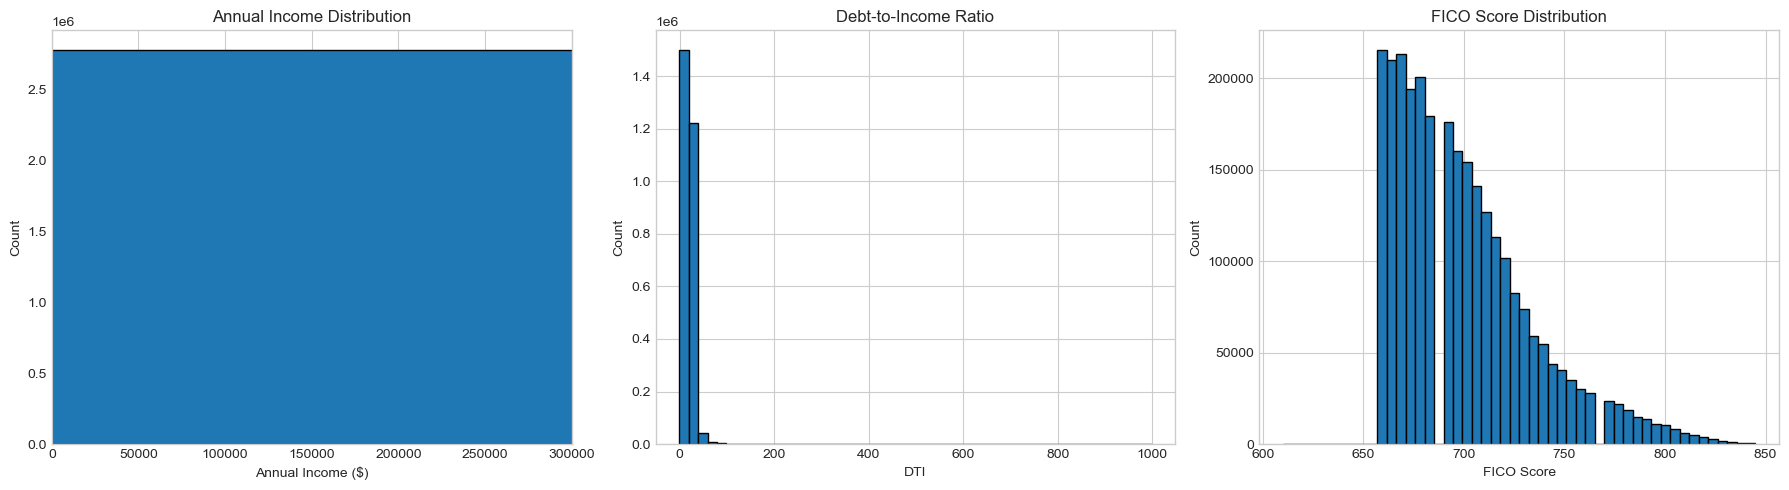

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['annual_inc'].dropna(), bins=50, edgecolor='black')
axes[0].set_title('Annual Income Distribution')
axes[0].set_xlabel('Annual Income ($)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 300000)  # cap at 300k — extreme outliers skew the plot

axes[1].hist(df['dti'].dropna(), bins=50, edgecolor='black')
axes[1].set_title('Debt-to-Income Ratio')
axes[1].set_xlabel('DTI')
axes[1].set_ylabel('Count')

axes[2].hist(df['fico_range_low'].dropna(), bins=50, edgecolor='black')
axes[2].set_title('FICO Score Distribution')
axes[2].set_xlabel('FICO Score')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

- **Annual income:** Heavy right skew with extreme outliers : needs log-transform or capping before modeling.
- **DTI:** Most borrowers have manageable debt loads. LendingClub screens out extreme DTI borrowers.
- **FICO:** Looks like the right half of a bell curve, the left tail is cut off because LendingClub has a minimum FICO requirement. This is a selection effect.

## Summary and Key Findings

**Data:** 2.7 million loans across 19 quarterly files from LendingClub (2010-2019), 
trimmed to 34 columns relevant to an investor's decision-making framework.

**Key Findings:**

- **Grade:** Default rates increase linearly from ~9% (Grade A) 
  to ~55% (Grade G), mirroring interest rates from 7.2% to 28%. The risk-return 
  tradeoff is real but not straightforward — higher grades aren't necessarily better 
  investments once you account for interest income.

- **Purpose:** Small business and educational loans default at the highest rates. 
  Debt consolidation dominates volume (~56% of all loans) with moderate default risk.

- **Temporal patterns:** Default rates spiked in 2008 (Global Financial Crisis) and 
  appear to drop sharply post-2017 — but this is a data artifact. Recent loans haven't 
  had enough time to reach their final status. For modeling, we filter to pre-2018 loans.

- **Class imbalance:** ~10.2% of loans default — but this understates the true default 
  rate since 1.56M current loans haven't resolved yet.

- **Missing values:** `mths_since_last_delinq` is 52% missing (missing = never delinquent). 
  `sec_app_fico_*` is 93% missing (joint applications only). Both need careful handling.

- **Data leakage warning:** `grade` and `sub_grade` are derived by LendingClub's internal 
  model, not raw borrower characteristics. Including them inflates model performance. 
  Phase 3 investigates their impact explicitly.

**Open Questions for Phase 2 and 3:**

- Which features are most predictive of default after removing LendingClub-derived features?
- Can a model built on raw borrower characteristics beat LendingClub's own grade assignment?
- Which investment strategy — default-based, return-based, or combined produces the 
  best risk-adjusted returns across different return assumptions?

In [46]:
import pickle

# At the end of Phase 1 notebook
pickle.dump(df, open('../Phase1/phase1_output.pickle', 'wb'))

In [47]:
df.columns

Index(['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'grade', 'sub_grade',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'issue_d', 'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'open_acc', 'pub_rec', 'fico_range_high', 'fico_range_low', 'revol_bal',
       'revol_util', 'inq_last_6mths', 'pub_rec_bankruptcies', 'addr_state',
       'total_acc', 'mths_since_last_delinq', 'sec_app_fico_range_high',
       'sec_app_fico_range_low', 'id', 'loan_status', 'total_pymnt',
       'recoveries', 'out_prncp', 'last_fico_range_high',
       'last_fico_range_low', 'last_pymnt_d', 'is_default'],
      dtype='object')